# WFSS Spectra Part 1: Combine and Normalize 1D Spectra

**Use case:** optimal extraction of grism spectra; redshift measurement; emission-line maps.  Simplified version of [JDox Science Use Case # 33](https://jwst-docs.stsci.edu/near-infrared-imager-and-slitless-spectrograph/niriss-example-science-programs/niriss-wfss-with-nircam-parallel-imaging-of-galaxies-in-lensing-clusters).<br>
**Data:** JWST simulated NIRISS images from [MIRAGE](https://jwst-docs.stsci.edu/jwst-other-tools/mirage-data-simulator), run through the [JWST calibration pipeline](https://jwst-pipeline.readthedocs.io/en/latest/); galaxy cluster.<br>
**Tools:**  specutils, astropy, pandas, emcee, lmfit, corner, h5py.<br>
**Cross-intrument:** NIRSpec <br>
**Documentation:** This notebook is part of a STScI's larger [post-pipeline Data Analysis Tools Ecosystem](https://jwst-docs.stsci.edu/jwst-post-pipeline-data-analysis).<br>


## Introduction

This notebook is 2 of 4 in a set focusing on NIRISS WFSS data:
    1. 1D optimal extraction since the JWST pipeline only provides a box extraction.  Optimal extraction improves S/N of spectra for faint sources.
    2. Combine and normalize 1D spectra.
    3. Cross correlate galaxy with template to get redshift.
    4. Spatially resolved emission line map.
    
This notebook will first combine optimally extracted 1D spectra (from #1) at different dither positions.  The combined spectrum will then be normalized by flux estimated from direct images (i.e. broadband photometry).

This notebook will start with an optimally extracted 1D spectrum in the previous notebook, saved in a file with a name similar to "l3_nis_f115w_G150C_s00002_ndither0_1d_opt.fits".  The various one-dimensional spectra from each dither will be combined and saved into a single file, named like "l3_nis_f115w_G150C_s00004_combine_1d_opt.fits". 

**Note:** The procedure is not intended to combine spectra from the two different orientations (C&R), as each has a different spectral resolution depending on source morphology.

**Note:** Normalization of grism spectrum to each broadband filter photometry will improve zeropoint calibration, which is critical in continuum fitting over multiple filters.

In [1]:
%matplotlib inline

In [2]:
import os
import numpy as np
from scipy.integrate import simpson
from urllib.request import urlretrieve
import tarfile

from astropy.io import fits
import astropy.units as u
from astropy.io import ascii

import astropy
print('astropy', astropy.__version__)

astropy 8.0.1


In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# These gymnastics are needed to make the sizes of the figures
# be the same in both the inline and notebook versions
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

mpl.rcParams['savefig.dpi'] = 80
mpl.rcParams['figure.dpi'] = 80

In [4]:
import specutils
from specutils import Spectrum
from astropy.nddata import StdDevUncertainty

print("Specutils: ", specutils.__version__)

Specutils:  2.4.0


### 0. Download notebook 01 products
These can be also obtained by running the notebooks.

In [5]:
if not os.path.exists('./output'):
    import zipfile
    import urllib.request
    boxlink = 'https://data.science.stsci.edu/redirect/JWST/jwst-data_analysis_tools/NIRISS_lensing_cluster/output.zip'
    boxfile = './output.zip'
    urllib.request.urlretrieve(boxlink, boxfile)
    zf = zipfile.ZipFile(boxfile, 'r')
    list_names = zf.namelist()
    for item in list_names:
        zf.extract(member=item) # Using extract instead of extractall because it is safer when files have absolute (/) or relative (..) paths
else:
    print('Already exists')

Already exists


In [6]:
# Which data set?;
DIR_OUT = './output/'
filt = 'f200w'
grism = 'G150C'
id = '00004'
ndither = 2 # Number of dithering positions.

### 1.Combine spectra from different dithers;

In [7]:
dithers = np.arange(0, ndither, 1)
for dither in dithers:
    file_1d = f'{DIR_OUT}l3_nis_{filt}_{grism}_s{id}_ndither{dither}_1d_opt.fits'
    fd = fits.open(file_1d)[1].data
    if dither == 0:
        wave = fd['wavelength']
        flux = np.zeros((ndither, len(wave)), 'float')
        flux_err = np.zeros((ndither, len(wave)), 'float')
        flux[dither, :] = fd['flux']
        flux_err[dither, :] = fd['uncertainty']
    else:
        wave_tmp = fd['wavelength']
        flux_tmp = fd['flux']
        flux_err_tmp = fd['uncertainty']
        
        flux[dither, :] = np.interp(wave, wave_tmp, flux_tmp)
        flux_err[dither, :] = np.sqrt(np.interp(wave, wave_tmp, flux_err_tmp[:]**2))

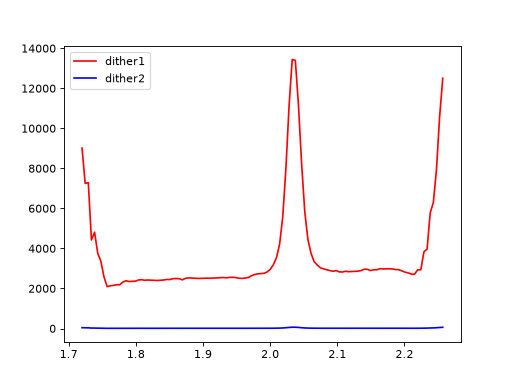

In [8]:
plt.plot(wave, flux[0, :], color='r', label='dither1')
plt.plot(wave, flux[1, :], color='b', label='dither2')
plt.legend(loc=2)

### Make weighted-average of the two spectra from different dither positions;

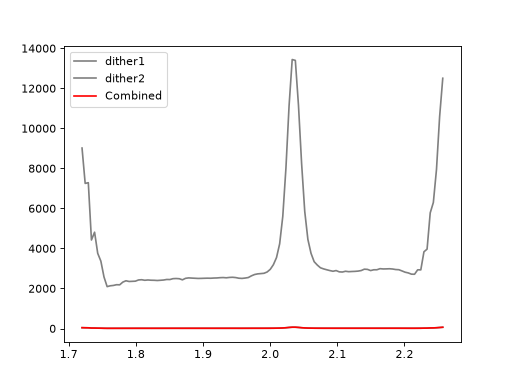

In [9]:
flux_combine = np.zeros(len(wave), 'float')
flux_err_combine = np.zeros(len(wave), 'float')

for ii in range(len(wave)):
    flux_combine[ii] = np.sum(flux[:, ii] * 1 / flux_err[:, ii]**2) / np.sum(1 / flux_err[:, ii]**2) 
    flux_err_combine[ii] = np.sqrt(np.sum(flux_err[:, ii]**2)) / len(flux_err[:, ii])

plt.plot(wave, flux[0, :], color='gray', label='dither1')
plt.plot(wave, flux[1, :], color='gray', label='dither2')
plt.plot(wave, flux_combine[:], color='r', label='Combined')
plt.legend(loc=2)

### 2.Continuum normalization;
Since NIRISS spectra may be affected background subtraction & contamination, which could lead to mismatch between filters, here we aim to normaliza spectra from filter to its broadband magnitude.

In [10]:
# Open broadband flux catalog from Notebook 01a;

# Flux are already in Fnu, with magzp = 25.0;
file = DIR_OUT + 'l3_nis_flux.cat'

fd_cat = ascii.read(file)
id_cat = fd_cat['id']
magzp = 25.0

fd_cat

id,F309,E309,F310,E310,F311,E311,F308,E308,F1,E1,F4,E4,F6,E6,F202,E202,F203,E203,F204,E204,F205,E205
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,4.17638,0.208819,13.9316,0.696578,15.8489,0.792447,2.39883,0.119942,0.29134,0.014567,1.45747,0.0728736,2.22433,0.111217,3.49623,0.174812,6.11505,0.305752,10.5682,0.528409,14.9279,0.746397
2,4.17638,0.208819,13.9316,0.696578,15.8489,0.792447,2.39883,0.119942,0.29134,0.014567,1.45747,0.0728736,2.22433,0.111217,3.49623,0.174812,6.11505,0.305752,10.5682,0.528409,14.9279,0.746397
3,4.17638,0.208819,13.9316,0.696578,15.8489,0.792447,2.39883,0.119942,0.29134,0.014567,1.45747,0.0728736,2.22433,0.111217,3.49623,0.174812,6.11505,0.305752,10.5682,0.528409,14.9279,0.746397
4,11.2928,0.564638,16.2032,0.810159,15.8489,0.792447,7.68422,0.384211,5.01649,0.250825,6.48634,0.324317,6.8612,0.34306,8.86339,0.44317,14.0217,0.701084,16.248,0.8124,16.2181,0.810905
5,7.23103,0.361551,6.29216,0.314608,6.30957,0.315479,5.6079,0.280395,0.175227,0.00876133,0.206633,0.0103317,2.71144,0.135572,7.08598,0.354299,6.86752,0.343376,6.46845,0.323422,6.36796,0.318398
6,7.23103,0.361551,6.29216,0.314608,6.30957,0.315479,5.6079,0.280395,0.175227,0.00876133,0.206633,0.0103317,2.71144,0.135572,7.08598,0.354299,6.86752,0.343376,6.46845,0.323422,6.36796,0.318398
7,7.23103,0.361551,6.29216,0.314608,6.30957,0.315479,5.6079,0.280395,0.175227,0.00876133,0.206633,0.0103317,2.71144,0.135572,7.08598,0.354299,6.86752,0.343376,6.46845,0.323422,6.36796,0.318398


In [11]:
# Retrieve filter curves for NIRISS images;
url = 'https://jwst-docs.stsci.edu/files/216454094/216454098/1/1762450948325/niriss_filter_tarball.tar'

filename = 'tmp.tar.gz'
urlretrieve(url, filename)
my_tar = tarfile.open(filename)
my_tar.extractall('./', filter='data') # add filter='data' to skip absolute (/) or relative (..) paths

Wavelength FilterTrans     PCE    
---------- ----------- -----------
       0.5         0.0         0.0
     0.501         0.0         0.0
     0.502         0.0         0.0
     0.503         0.0         0.0
     0.504         0.0         0.0
     0.505         0.0         0.0
     0.506         0.0         0.0
     0.507         0.0         0.0
     0.508         0.0         0.0
     0.509         0.0         0.0
       ...         ...         ...
     5.491 1.15901e-06 5.88441e-08
     5.492 1.17562e-06  5.8551e-08
     5.493 1.19224e-06 5.82397e-08
     5.494 1.20426e-06  5.7781e-08
     5.495 1.21578e-06 5.72767e-08
     5.496  1.2271e-06 5.68508e-08
     5.497 1.23762e-06 5.63651e-08
     5.498 1.24814e-06 5.58675e-08
     5.499         0.0         0.0
       5.5         0.0         0.0
Length = 5001 rows


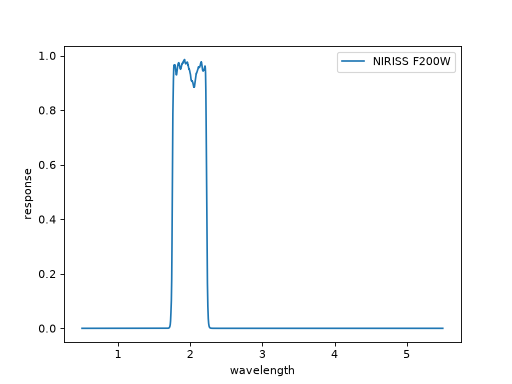

In [12]:
# Load fiter response:
DIR_FIL = './niriss_filter_tarball/DATA/'

# The number corresponds to F200W in EAZY filter response;
eazy_filt = 311

# Read transmission data;
filt_data = ascii.read(f'{DIR_FIL}/NIRISS_{filt.upper()}.txt')

print(filt_data)
wave_filt = filt_data['Wavelength']
flux_filt = filt_data['FilterTrans']

plt.plot(wave_filt, flux_filt, ls='-', label=f'NIRISS {filt.upper()}')
plt.xlabel('wavelength')
plt.ylabel('response')
plt.legend(loc=1)

In [13]:
# Define a small function for flux convolution with filters;
def filconv(lfil, ffil, l0, f0, DIR='', c=3e18):
    '''
    lfil : Wave array for filter response curve.
    ffil : Flux array for filter response curve.

    l0 : Wave array for spectrum, in f_nu, not f_lam
    f0 : Flux array for spectrum, in f_nu, not f_lam

    '''

    fhalf = np.max(ffil)/2.0
    con = (ffil > fhalf)
    lfwhml = np.min(lfil[con])
    lfwhmr = np.max(lfil[con])
    lcen = (lfwhmr + lfwhml)/2.

    lamS, spec = l0, f0  # Two columns with wavelength and flux density
    lamF, filt = lfil, ffil  # Two columns with wavelength and response in the range [0,1]
    filt_int = np.interp(lamS, lamF, filt)  # Interpolate Filter to common(spectra) wavelength axis

    if len(lamS) > 0:
        I1 = simpson(spec / lamS**2 * c * filt_int * lamS, x=lamS)  # Denominator for Fnu
        I2 = simpson(filt_int/lamS, x=lamS) # Numerator
        fnu = I1/I2/c # Average flux density
    else:
        I1 = 0
        I2 = 0
        fnu = 0

    return lcen, fnu

In [14]:
# Convolve observed spectrum with the filter response.
# The input flux need to be in Fnu with magzp=25;

# Cut edge of observed flux;
con = (wave > 1.75) & (wave < 2.25)
lcen, fnu = filconv(wave_filt, flux_filt, wave[con], flux_combine[con], DIR='./')
print('Central wavelength and total flux are ;', lcen, fnu)

Central wavelength and total flux are ; 1.9885 15.889336490855992


In [15]:
# Get normalization factor;
iix = np.where(id_cat[:] == int(id))
Cnorm = fd_cat[f'F{eazy_filt}'][iix] / fnu 
Cnorm

0.997455117721293


In [16]:
# Wirte the normalized spectrum:
# Make it into a Spectrum instance.
file_1d = f'{DIR_OUT}l3_nis_{filt}_{grism}_s{id}_ndither{dither}_1d_opt.fits'

obs = Spectrum(spectral_axis=wave*u.um,
               flux=flux_combine * Cnorm * u.dimensionless_unscaled,
               uncertainty=StdDevUncertainty(flux_err_combine * Cnorm), unit='')
obs.write(file_1d, format='tabular-fits', overwrite=True)

### Repeat 1&2 for other filters too;

In [17]:
DIR_FIL = './niriss_filter_tarball/DATA/'
filts = ['f115w', 'f150w', 'f200w']
# The number corresponds to NIRISS filters in EAZY filter response;
eazy_filts = [309, 310, 311]

# Masks for problematic flux at edge;
mask_lw = [1.05, 1.35, 1.75]
mask_uw = [1.25, 1.65, 2.23]

for ff, filt in enumerate(filts):
    for dither in dithers:
        file_1d = f'{DIR_OUT}l3_nis_{filt}_{grism}_s{id}_ndither{dither}_1d_opt.fits'
        fd = fits.open(file_1d)[1].data
        if dither == 0:
            wave = fd['wavelength']
            flux = np.zeros((ndither, len(wave)), 'float')
            flux_err = np.zeros((ndither, len(wave)), 'float')

            flux[dither, :] = fd['flux']
            flux_err[dither, :] = fd['uncertainty']
        else:
            wave_tmp = fd['wavelength']
            flux_tmp = fd['flux']
            flux_err_tmp = fd['uncertainty']

            flux[dither, :] = np.interp(wave, wave_tmp, flux_tmp)
            flux_err[dither, :] = np.sqrt(np.interp(wave, wave_tmp, flux_err_tmp[:]**2))

    # Combine;
    flux_combine = np.zeros(len(wave), 'float')
    flux_err_combine = np.zeros(len(wave), 'float')

    for ii in range(len(wave)):
        flux_combine[ii] = np.sum(flux[:, ii] * 1 / flux_err[:, ii]**2) / np.sum(1 / flux_err[:, ii]**2) 
        flux_err_combine[ii] = np.sqrt(np.sum(flux_err[:, ii]**2)) / len(flux_err[:, ii])

    # Normalize;
    filt_data = ascii.read(f'{DIR_FIL}/NIRISS_{filt.upper()}.txt')
    wave_filt = filt_data['Wavelength']
    flux_filt = filt_data['FilterTrans']

    con = (wave > mask_lw[ff]) & (wave < mask_uw[ff])
    lcen, fnu = filconv(wave_filt, flux_filt, wave[con], flux_combine[con])
    iix = np.where(id_cat[:] == int(id))
    Cnorm = fd_cat[f'F{eazy_filts[ff]}'][iix] / fnu

    # Write:
    file_1d = f'{DIR_OUT}l3_nis_{filt}_{grism}_s{id}_combine_1d_opt.fits' 
    
    obs = Spectrum(spectral_axis=wave*u.um,
                   flux=flux_combine * Cnorm * u.dimensionless_unscaled,
                   uncertainty=StdDevUncertainty(flux_err_combine * Cnorm), unit='')
    obs.write(file_1d, format='tabular-fits', overwrite=True)

### Results;
The spectra are align with each other, as they are matched to BB photometry.

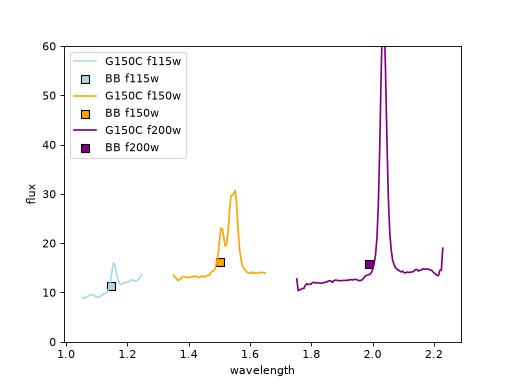

In [18]:
filts = ['f115w', 'f150w', 'f200w']
cols = ['lightblue', 'orange', 'purple']

for ff, filt in enumerate(filts):
    file_1d = f'{DIR_OUT}l3_nis_{filt}_{grism}_s{id}_combine_1d_opt.fits' 
    fd = fits.open(file_1d)[1].data
    wave = fd['wavelength']
    flux = fd['flux']
    flux_err = fd['uncertainty']

    con = (wave > mask_lw[ff]) & (wave < mask_uw[ff])
    plt.plot(wave[con], flux[con], ls='-', label=f'{grism} {filts[ff]}', color=cols[ff])

    filt_data = ascii.read(f'{DIR_FIL}/NIRISS_{filt.upper()}.txt')
    wave_filt = filt_data['Wavelength']
    flux_filt = filt_data['FilterTrans']

    con = (wave > mask_lw[ff]) & (wave < mask_uw[ff])
    lcen, fnu = filconv(wave_filt, flux_filt, wave[con], flux[con])
    iix = np.where(id_cat[:] == int(id))
    plt.scatter(lcen, fd_cat[f'F{eazy_filts[ff]}'][iix], marker='s', s=50, edgecolor='k', color=cols[ff], label=f'BB {filts[ff]}')


plt.xlabel('wavelength')
plt.ylabel('flux')
plt.ylim(0, 60)
plt.legend(loc=0)

### Repeat for another target;

In [19]:
id = '00003'

filts = ['f115w', 'f150w', 'f200w']
eazy_filts = [309, 310, 311]
DIR_FIL = './niriss_filter_tarball/DATA/'

# Masks for problematic flux at edge;
mask_lw = [1.05, 1.35, 1.75]
mask_uw = [1.25, 1.65, 2.23]

for ff, filt in enumerate(filts):
        
    for dither in dithers:
        file_1d = f'{DIR_OUT}l3_nis_{filt}_{grism}_s{id}_ndither{dither}_1d_opt.fits'
        fd = fits.open(file_1d)[1].data
        if dither == 0:
            wave = fd['wavelength']
            flux = np.zeros((ndither, len(wave)), 'float')
            flux_err = np.zeros((ndither, len(wave)), 'float')

            flux[dither, :] = fd['flux']
            flux_err[dither, :] = fd['uncertainty']
        else:
            wave_tmp = fd['wavelength']
            flux_tmp = fd['flux']
            flux_err_tmp = fd['uncertainty']

            flux[dither, :] = np.interp(wave, wave_tmp, flux_tmp)
            flux_err[dither, :] = np.sqrt(np.interp(wave, wave_tmp, flux_err_tmp[:]**2))

    # Combine;
    flux_combine = np.zeros(len(wave), 'float')
    flux_err_combine = np.zeros(len(wave), 'float')

    for ii in range(len(wave)):
        flux_combine[ii] = np.sum(flux[:, ii] * 1 / flux_err[:, ii]**2) / np.sum(1 / flux_err[:, ii]**2) 
        flux_err_combine[ii] = np.sqrt(np.sum(flux_err[:, ii]**2)) / len(flux_err[:, ii])

    # Normalize;
    filt_data = ascii.read(f'{DIR_FIL}/NIRISS_{filt.upper()}.txt')
    wave_filt = filt_data['Wavelength']
    flux_filt = filt_data['FilterTrans']

    con = (wave > mask_lw[ff]) & (wave < mask_uw[ff])
    lcen, fnu = filconv(wave_filt, flux_filt, wave[con], flux_combine[con])
    iix = np.where(id_cat[:] == int(id))
    Cnorm = fd_cat[f'F{eazy_filts[ff]}'][iix] / fnu
        
    # Write:
    file_1d = f'{DIR_OUT}l3_nis_{filt}_{grism}_s{id}_combine_1d_opt.fits'
    obs = Spectrum(spectral_axis=wave*u.um,
                   flux=flux_combine * Cnorm * u.dimensionless_unscaled,
                   uncertainty=StdDevUncertainty(flux_err_combine * Cnorm), unit='')
    obs.write(file_1d, format='tabular-fits', overwrite=True)

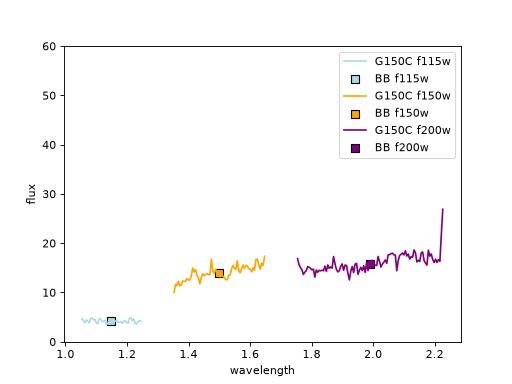

In [20]:
filts = ['f115w', 'f150w', 'f200w']
cols = ['lightblue', 'orange', 'purple']

for ff, filt in enumerate(filts):
    file_1d = f'{DIR_OUT}l3_nis_{filt}_{grism}_s{id}_combine_1d_opt.fits' 
    fd = fits.open(file_1d)[1].data
    wave = fd['wavelength']
    flux = fd['flux']
    flux_err = fd['uncertainty']

    con = (wave > mask_lw[ff]) & (wave < mask_uw[ff])
    plt.plot(wave[con], flux[con], ls='-', label=f'{grism} {filts[ff]}', color=cols[ff])

    filt_data = ascii.read(f'{DIR_FIL}/NIRISS_{filt.upper()}.txt')
    wave_filt = filt_data['Wavelength']
    flux_filt = filt_data['FilterTrans']

    con = (wave > mask_lw[ff]) & (wave < mask_uw[ff])
    lcen, fnu = filconv(wave_filt, flux_filt, wave[con], flux[con])
    iix = np.where(id_cat[:] == int(id))
    plt.scatter(lcen, fd_cat[f'F{eazy_filts[ff]}'][iix], marker='s', s=50, edgecolor='k', color=cols[ff], label=f'BB {filts[ff]}')

plt.xlabel('wavelength')
plt.ylabel('flux')
plt.ylim(0, 60)
plt.legend(loc=0)